<a href="https://colab.research.google.com/github/glender222/FATIGA-MODEL-PRELIMINAR/blob/main/fatiga_cognitiva_prueba_preliminar2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estimación de fatiga cognitiva — modelo pasivo (preliminar)

**Qué hace este notebook, en simple:** tenemos una tabla donde cada fila es un momento en que una persona reportó su fatiga (0–100) junto con cuánto usó el celular justo antes. Vamos a entrenar varios modelos para *estimar* la fatiga a partir del uso del celular, y compararlos de forma justa.

**Plan (secciones):**
0. Setup — instalar librerías
1. Cargar el CSV y mirarlo  ← *hoy*
2. Construir el objetivo (target) y la partición anti-fuga
3. Features
4. Modelos: baselines → Ridge/LightGBM → TabPFN → red temporal → GNN
5. Tabla comparativa final

> Cada modelo se evalúa con la **misma partición** y la **misma métrica** → comparación justa.

## Sección 0 — Setup

Instala las librerías que iremos usando. En Colab, `pandas`, `numpy`, `scikit-learn`, `torch` y `lightgbm` casi siempre ya vienen. Las nuevas (`tabpfn`, `torch-geometric`) las instalamos cuando lleguemos a esos modelos, para no esperar de gana ahora.

Corre esta celda una vez. Si algo ya está instalado, no pasa nada.

In [ ]:
# Librerías base (en Colab normalmente ya están; esto es por si acaso)
!pip install -q pandas numpy scikit-learn lightgbm

# Estas las activaremos más adelante, en su sección. Por ahora déjalas comentadas:
# !pip install -q tabpfn                 # Sección 4 - TabPFN
# !pip install -q torch-geometric        # Sección 4 - GNN

import pandas as pd
import numpy as np
print("Listo. pandas", pd.__version__, "| numpy", np.__version__)

Listo. pandas 2.2.2 | numpy 2.0.2


## Sección 1 — Cargar el CSV y mirarlo

Primero subimos `appData.csv`. En Colab, al correr la celda te saldrá un botón para subir el archivo desde tu compu. (Si lo subiste al panel de archivos de Colab a la izquierda, también lo detecta solo.)

In [ ]:
import os

PATH = 'appData.csv'

# Si estamos en Colab y el archivo no está, pide subirlo
if not os.path.exists(PATH):
    try:
        from google.colab import files
        print("Sube tu archivo appData.csv:")
        uploaded = files.upload()
        PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("No encuentro appData.csv. Súbelo a la carpeta del notebook.")

df = pd.read_csv(PATH)
print("Archivo cargado:", PATH)
print("Forma (filas, columnas):", df.shape)

Sube tu archivo appData.csv:


Saving appData.csv to appData.csv
Archivo cargado: appData.csv
Forma (filas, columnas): (3234, 26)


### Primer vistazo: ¿qué columnas hay?

Miramos las primeras filas. Lo importante de entender:
- `pp` = id de la persona (participante)
- `day`, `time` = qué día y a qué hora del día
- `fatigue` = lo que queremos estimar (0–100). **Ojo: muchas filas la tienen vacía** (NaN); esos son momentos sin reporte, que descartaremos.
- `total_b10/b20/b30` = uso del celular en los 10/20/30 min **antes** del reporte (la "b" es *before*). **Estas son nuestra señal pasiva.**
- `total_a10/a20/a30` = uso **después** (la "a" es *after*). **NO las usaremos**: serían trampa (fuga de información del futuro).

In [ ]:
df.head()

,pp,age,gender,yearPhD,faculty,day,time,fatigue,boredom,total_b10,...,endWork,startBreak,endBreak,privateUse,smartphoneCheck,smartphoneUse,fomo1,fomo2,fomo3,exactTime
0,1,28,female,4,arts,1,8,NaN,NaN,NaN,...,15:40:00,11:05:00,11:40:00,80.0,5,4,2,2,2,NaN
1,1,28,female,4,arts,1,9,NaN,NaN,NaN,...,15:40:00,11:05:00,11:40:00,80.0,5,4,2,2,2,NaN
2,1,28,female,4,arts,1,10,12.0,10.0,0.0,...,15:40:00,11:05:00,11:40:00,80.0,5,4,2,2,2,10:03:58
3,1,28,female,4,arts,1,11,10.0,11.0,0.0,...,15:40:00,11:05:00,11:40:00,80.0,5,4,2,2,2,11:00:39
4,1,28,female,4,arts,1,12,17.0,16.0,0.0,...,15:40:00,11:05:00,11:40:00,80.0,5,4,2,2,2,12:04:06


### ¿Cuántos datos reales tenemos?

Nos quedamos mentalmente solo con las filas que **sí** tienen `fatigue` reportada: esos son los ejemplos que el modelo puede aprender. Y miramos cuántos reportes dio cada persona (esto importará en la Sección 2).

In [ ]:
# Filas con fatiga reportada = ejemplos utilizables
con_fatiga = df[df['fatigue'].notna()]

print("Filas totales:          ", len(df))
print("Filas con fatiga (útiles):", len(con_fatiga))
print("Personas distintas:     ", df['pp'].nunique())

# Reportes por persona
reportes = con_fatiga.groupby('pp').size()
print("\nReportes por persona -> mínimo:", reportes.min(),
      "| mediana:", int(reportes.median()),
      "| máximo:", reportes.max())
print("Personas con menos de 8 reportes:", (reportes < 8).sum())

Filas totales:           3234
Filas con fatiga (útiles): 1991
Personas distintas:      98

Reportes por persona -> mínimo: 2 | mediana: 21 | máximo: 30
Personas con menos de 8 reportes: 3


**Cómo leer este resultado:** si la mayoría de personas tiene bastantes reportes (mediana alta), podremos calcular un "nivel normal de fatiga" confiable para cada una en la Sección 2. Si muchas tuvieran 2–3 reportes, ese nivel sería puro ruido.

✅ Hasta aquí la Sección 1. Cuando entiendas esto, seguimos con la **Sección 2: el target y la partición** (la parte conceptualmente más importante).

## Sección 2 — El objetivo (target) y la partición anti-fuga

Esta es la sección más importante. Acá decidimos **dos cosas**:

### Decisión 1: ¿qué número va a predecir el modelo?

No vamos a predecir la fatiga cruda (ej. "40"), sino la **desviación respecto al nivel normal de cada persona**.

**¿Por qué?** Cada persona tiene un nivel base distinto: hay gente que de carácter reporta 30 y gente que reporta 70. Si predecimos el valor crudo, el modelo gasta su esfuerzo en adivinar "quién es" cada persona, no en leer la señal del celular. Nos interesa lo otro: *dado que conozco tu normal, ¿hoy estás por encima o por debajo?*

> Ejemplo: Ana normalmente ronda 30 de fatiga. Si en un momento reporta 45, su **desviación = +15**. Eso (el +15) es lo que el modelo intenta estimar a partir del uso del celular.

Esto se llama **normalización intra-persona** (*within-person*), y es estándar en la literatura de *digital phenotyping* [2,4]. El propio estudio que generó estos datos modeló con efectos que varían por participante [1].

### Decisión 2: ¿cómo separamos datos para entrenar y para evaluar?

Partimos la línea de tiempo de **cada persona** en dos:
- **Primera mitad (calibración):** la usamos para aprender el "nivel normal" de esa persona.
- **Segunda mitad (evaluación):** ahí medimos qué tan bien predice el modelo.

**¿Por qué en orden de tiempo y no al azar?** Por dos razones:
1. **Realismo:** en tu app real, el celular conoce tu *pasado*, no tu futuro. Entrenar con el pasado y evaluar con el futuro imita el uso real.
2. **Evitar fuga (leakage):** si mezcláramos pasado y futuro al azar, el modelo podría "espiar" información que en la vida real no tendría. El nivel normal lo calculamos **solo con la calibración**, nunca con datos de evaluación.

In [ ]:
import numpy as np

# Partimos de las filas con fatiga (las útiles), ordenadas por persona y tiempo
d = df[df['fatigue'].notna()].copy()
d = d.sort_values(['pp', 'day', 'time']).reset_index(drop=True)

# Para cada persona: numeramos sus reportes en orden (0,1,2,...) y contamos cuántos tiene
d['orden'] = d.groupby('pp').cumcount()
d['n_pp']  = d.groupby('pp')['fatigue'].transform('size')

# Primera mitad = calibración ; segunda mitad = evaluación
corte = (d['n_pp'] * 0.5).astype(int)
d['set'] = np.where(d['orden'] < corte, 'calib', 'eval')

print("Ejemplos de calibración:", (d['set']=='calib').sum())
print("Ejemplos de evaluación: ", (d['set']=='eval').sum())

Ejemplos de calibración: 971
Ejemplos de evaluación:  1020


Ahora calculamos el **nivel normal (baseline)** de cada persona = su fatiga promedio, usando **solo** la calibración. Y definimos el **target = fatiga − su nivel normal**.

In [ ]:
# Nivel normal de cada persona, SOLO con datos de calibración (clave: no espiar el futuro)
baseline = d[d['set']=='calib'].groupby('pp')['fatigue'].mean().rename('baseline')
d = d.merge(baseline, on='pp', how='left')

# Si alguna persona no tuviera calibración, su baseline sería NaN -> la descartamos
d = d[d['baseline'].notna()].copy()

# EL TARGET: cuánto se desvió del nivel normal
d['target'] = d['fatigue'] - d['baseline']

print("Personas usables:", d['pp'].nunique())
print("\nEl target (desviación) en evaluación:")
print(d[d['set']=='eval']['target'].describe().round(2))

Personas usables: 98

El target (desviación) en evaluación:
count    1020.00
mean        2.53
std        19.43
min       -43.58
25%       -10.40
50%        -0.13
75%        14.66
max        63.91
Name: target, dtype: float64


### La vara: ¿contra qué comparamos a los modelos?

Antes de entrenar nada, necesitamos un mínimo a vencer. Si un modelo no le gana a estas "apuestas tontas", no sirve.

- **Vara A — predecir 0 desviación:** apostar siempre "esta persona está en su nivel normal". Esto ya aprovecha el baseline personal.
- **Vara B — predecir el promedio global:** apostar el promedio de todos, sin personalizar.

Medimos el error con **MAE** (error absoluto medio): en promedio, ¿por cuántos puntos 0–100 nos equivocamos?

In [ ]:
ev = d[d['set']=='eval']

# Vara A: predecir 0 de desviación
mae_A = ev['target'].abs().mean()

# Vara B: predecir el promedio global de fatiga (calculado en calibración)
prom_global = d[d['set']=='calib']['fatigue'].mean()
mae_B = (ev['fatigue'] - prom_global).abs().mean()

print(f"Vara A (predecir 0, con baseline personal): MAE = {mae_A:.2f}")
print(f"Vara B (promedio global, sin personalizar): MAE = {mae_B:.2f}")
print(f"\n>>> La vara a vencer por los modelos es: {mae_A:.2f} puntos <<<")

Vara A (predecir 0, con baseline personal): MAE = 15.27
Vara B (promedio global, sin personalizar): MAE = 17.83

>>> La vara a vencer por los modelos es: 15.27 puntos <<<


**Cómo leer esto:**
- La **Vara A** es el número clave: si solo sé tu nivel normal y siempre apuesto "estás normal", me equivoco ~15 puntos. **Cualquier modelo con señal del celular tiene que bajar de ahí.**
- Que la Vara A sea mejor (más baja) que la B confirma que personalizar ayuda → la Decisión 1 fue correcta.

✅ Fin de la Sección 2. Ya tenemos: el target, la partición sin fuga, y la vara. En la **Sección 3** construimos las *features* (las señales del celular que entran al modelo), y en la **Sección 4** empiezan a competir los 5 modelos.

## Sección 3 — Features (las señales que entran al modelo)

Una **feature** es cada número que le damos al modelo como pista para adivinar. Acá las construimos a partir del uso del celular.

Tenemos tres tipos:

**1. Crudas (el uso tal cual):**
- `total_b10`, `total_b20`, `total_b30` → segundos de uso del celular en los 10/20/30 min antes del reporte
- `time` → la hora del día (de 8 a 18). La metemos porque la fatiga tiene patrón circadiano: no es lo mismo a las 9am que a las 5pm.

**2. Centradas por persona (el truco *within-person*):**
Igual que con la fatiga, lo que importa no es cuánto usas el celular *en general*, sino cuánto te desviaste de *tu propio uso normal* ahora mismo. Así que restamos a cada uso el promedio de uso de esa persona (calculado solo en calibración).
- `total_b10_dev`, `total_b20_dev`, `total_b30_dev`

**3. ¿Agarró el celular o no? (motivada por el paper [1]):**
El estudio original encontró algo clave: la fatiga se relaciona con la **probabilidad de agarrar el teléfono**, no con cuánto tiempo lo usa [1]. Por eso agregamos una señal binaria: ¿hubo algún uso (>0) en la ventana de 20 min?
- `agarro_b20` → 1 si usó el celular, 0 si no

> Esta última es importante porque tus datos están llenos de ceros (mucha gente no toca el celular en la ventana). A veces *que lo agarres* dice más que *cuánto*.

In [ ]:
# --- Features crudas ---
crudas = ['total_b10', 'total_b20', 'total_b30', 'time']

# --- Features centradas por persona (uso - uso normal de esa persona, según calibración) ---
for c in ['total_b10', 'total_b20', 'total_b30']:
    uso_normal = d[d['set']=='calib'].groupby('pp')[c].mean().rename(c + '_mean')
    d = d.merge(uso_normal, on='pp', how='left')
    d[c + '_dev'] = d[c] - d[c + '_mean']

centradas = ['total_b10_dev', 'total_b20_dev', 'total_b30_dev']

# --- Feature binaria: ¿agarró el celular en la ventana de 20 min? ---
d['agarro_b20'] = (d['total_b20'] > 0).astype(int)
binaria = ['agarro_b20']

# Lista final de features
FEATURES = crudas + centradas + binaria
print("Usaremos", len(FEATURES), "features:")
for f in FEATURES:
    print("  -", f)

Usaremos 8 features:
  - total_b10
  - total_b20
  - total_b30
  - time
  - total_b10_dev
  - total_b20_dev
  - total_b30_dev
  - agarro_b20


Ahora armamos las **matrices** que comen los modelos: `X` (las features) e `y` (el target), separadas en calibración (entrenar) y evaluación (medir).

In [ ]:
calib = d[d['set']=='calib']
ev    = d[d['set']=='eval']

X_train = calib[FEATURES].fillna(0).values
y_train = calib['target'].values

X_eval  = ev[FEATURES].fillna(0).values
y_eval  = ev['target'].values

print("X_train:", X_train.shape, "  (filas para entrenar, columnas = features)")
print("X_eval: ", X_eval.shape,  "  (filas para evaluar)")
print("\nPrimeras filas de X_train (un vistazo):")
import pandas as pd
display(pd.DataFrame(X_train[:5], columns=FEATURES).round(1))

X_train: (971, 8)   (filas para entrenar, columnas = features)
X_eval:  (1020, 8)   (filas para evaluar)

Primeras filas de X_train (un vistazo):


,total_b10,total_b20,total_b30,time,total_b10_dev,total_b20_dev,total_b30_dev,agarro_b20
0,0.0,0.0,0.0,10.0,-68.0,-102.3,-123.0,0.0
1,0.0,125.0,125.0,11.0,-68.0,22.7,2.0,1.0
2,0.0,0.0,0.0,12.0,-68.0,-102.3,-123.0,0.0
3,0.0,0.0,58.0,13.0,-68.0,-102.3,-65.0,0.0
4,0.0,0.0,149.0,14.0,-68.0,-102.3,26.0,0.0


**Cómo leer esto:** cada fila de `X_train` es un momento; cada columna, una pista. El modelo verá estas pistas y tratará de adivinar el `y` (la desviación de fatiga).

Guardamos también `mae_A` (la vara = 15.27) que ya calculamos, para comparar a cada modelo contra ella.

✅ Fin de la Sección 3. Ya tenemos los datos listos para entrenar. En la **Sección 4** entran los modelos, uno por uno: empezamos por los baselines y los clásicos (Ridge, LightGBM), luego TabPFN, la red temporal y la GNN.

## Sección 4 — Los modelos compiten

Acá entrenamos los 5 enfoques y los comparamos **con la misma vara y la misma métrica (MAE)**. Lo hacemos por tandas:
- **Tanda 1:** baselines + clásicos (Ridge, LightGBM)  ← *esta*
- **Tanda 2:** TabPFN
- **Tanda 3:** red temporal (LSTM/GRU)
- **Tanda 4:** GNN

Primero, una funcioncita `evaluar()` que TODOS los modelos usarán, para que la comparación sea idéntica. Guarda cada resultado en `RESULTADOS` para la tabla final.

In [ ]:
# La vara (ya la teníamos): error de apostar siempre "desviación 0"
mae_A = np.abs(y_eval).mean()
print(f"VARA a vencer: MAE = {mae_A:.2f}\n")

RESULTADOS = {}   # aquí cada modelo deja su MAE

def evaluar(nombre, y_pred):
    mae = float(np.abs(y_eval - y_pred).mean())
    RESULTADOS[nombre] = mae
    print(f"{nombre:28s} MAE = {mae:.2f}   (vs vara: {mae - mae_A:+.2f})")
    return mae

# Registramos el baseline tonto como referencia
evaluar("Baseline (predecir 0)", np.zeros_like(y_eval))

VARA a vencer: MAE = 15.27

Baseline (predecir 0)        MAE = 15.27   (vs vara: +0.00)


15.265854469604472

### Modelo 1 — Ridge (regresión lineal regularizada)

El más simple: traza una relación lineal entre las features y la desviación de fatiga. "Regularizada" (el `alpha`) significa que lo frenamos para que no se obsesione con el ruido — importante cuando la señal es débil. Escalamos las features primero porque los modelos lineales son sensibles a la magnitud.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
ridge.fit(X_train, y_train)
evaluar("Ridge", ridge.predict(X_eval));

Ridge                        MAE = 14.42   (vs vara: -0.84)


### Modelo 2 — LightGBM (árboles con gradient boosting)

Construye muchos árboles de decisión pequeños, cada uno corrigiendo los errores del anterior. Capta relaciones no lineales (ej. "el uso importa solo a ciertas horas"). En datos tabulares suele ser el rey. Lo dejamos **regularizado** (pocas hojas, `min_child_samples` alto) porque con datos chicos y señal débil se sobreajusta fácil.

In [ ]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=200, num_leaves=15, learning_rate=0.03,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=0, verbose=-1
)
lgbm.fit(X_train, y_train)
evaluar("LightGBM", lgbm.predict(X_eval))

# Bonus: qué features mira el árbol
import pandas as pd
imp = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nImportancia de features (LightGBM):")
print(imp.to_string())

**Lo que deberías ver:** Ridge y LightGBM rondando **MAE ≈ 14.4**, ganándole a la vara (15.27) por ~0.8 puntos. Poco, pero real y en la dirección correcta: la señal del celular aporta *algo* sobre solo conocer tu nivel normal.

Dato honesto para el informe: mira la importancia de features — gran parte del aporte viene de `time` (hora del día), no tanto del uso del celular en sí. Coincide con el paper [1], que ya vio que la relación con el uso es débil.

✅ Fin de la Tanda 1. Sigue la **Tanda 2: TabPFN**, el modelo fundacional para datos tabulares pequeños [2].

### Tanda 2 — Modelo 3: TabPFN

**Qué es:** un "modelo fundacional" para tablas (salió en *Nature* 2025 [2]). En vez de aprender desde cero con tus datos, ya viene **pre-entrenado con millones de tablas sintéticas**, y resuelve tu problema en una sola pasada, sin ajustar hiperparámetros. Está pensado justo para datasets pequeños como el tuyo (971 filas, 8 features → le sobra capacidad).

**Por qué lo probamos:** es lo más nuevo y prometedor en datos tabulares; suele igualar o superar a LightGBM sin que toques nada.

⚠️ **Paso extra (una sola vez):** la versión actual pide aceptar una licencia gratuita para bajar los pesos. Es gratis:
1. Entra a https://ux.priorlabs.ai y regístrate (o inicia sesión)
2. Acepta la licencia en la pestaña *Licenses*
3. Copia tu API Key desde https://ux.priorlabs.ai/account
4. Pégala abajo en `TABPFN_TOKEN`

Si no quieres registrarte, no pasa nada: la celda se salta sola y seguimos con los demás modelos.

In [ ]:
!pip install -q tabpfn

import os
# >>> Pega aquí tu token gratuito (o déjalo vacío para saltar TabPFN) <<<
TABPFN_TOKEN = "tabpfn_sk_ypykPv339i8le0ibPVBHh8UxTZHdDwlVfF00LsU1qdw"   # ej: "tabpfn_xxx..."

if TABPFN_TOKEN:
    os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN

try:
    from tabpfn import TabPFNRegressor
    reg = TabPFNRegressor(device="cpu")   # en Colab con GPU puedes poner device="cuda"
    reg.fit(X_train, y_train)
    pred = reg.predict(X_eval)
    evaluar("TabPFN", pred)
except Exception as e:
    print("TabPFN no se ejecutó (probablemente falta el token).")
    print("Detalle:", str(e)[:200])
    print("\n>> Puedes seguir con el resto del notebook sin problema.")

TabPFN no se ejecutó (probablemente falta el token).
Detalle: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open http

>> Puedes seguir con el resto del notebook sin problema.


**Qué esperar:** dado que la señal pasiva es débil, lo más probable es que TabPFN aterrice cerca de Ridge/LightGBM (MAE ≈ 14–15). No hace magia: si la señal no está en los datos, ningún modelo la inventa. Su valor acá es ser una referencia "estado del arte, sin tuning" — si ni TabPFN baja mucho la vara, es evidencia fuerte de que el techo de la señal pasiva es bajo (justo el argumento del informe).

✅ Fin de la Tanda 2. Sigue la **Tanda 3: red temporal (LSTM/GRU)**, que aprovecha la secuencia en el tiempo de cada persona.

### Tanda 3 — Modelo 4: Red temporal (GRU)

**La idea nueva:** hasta ahora cada momento se evaluaba aislado. Pero una persona tiene una *trayectoria*: cómo venías en los reportes anteriores puede ayudar a estimar cómo estás ahora. Una **red recurrente (GRU)** lee una secuencia de los últimos K reportes y de ahí estima la desviación actual. Es el enfoque que usa la literatura de *passive sensing* para señales que evolucionan en el tiempo [4].

**Cómo lo armamos:** para cada reporte, tomamos sus features y las de los 4 anteriores (K=5 pasos). Si no hay suficientes anteriores (inicio de la persona), rellenamos con ceros. El objetivo sigue siendo el mismo: la desviación de fatiga.

**Importante:** escalamos las features en una copia aparte, para no alterar los datos que usará la GNN después. Y el escalado se ajusta solo con calibración (sin espiar evaluación).

In [ ]:
import torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler
torch.manual_seed(0); np.random.seed(0)

# --- escalar features en una COPIA (no tocamos d) ---
sc_seq = StandardScaler().fit(d.loc[d['set']=='calib', FEATURES].fillna(0))
dd = d[['pp','day','time','target','set']].copy()
dd[FEATURES] = sc_seq.transform(d[FEATURES].fillna(0))

# --- construir secuencias por persona: últimos K reportes -> desviación actual ---
K = 5
def construir_secuencias(dd, K, FEATURES):
    Xs, ys, sets = [], [], []
    for pp, g in dd.groupby('pp'):
        g = g.sort_values(['day','time'])
        F = g[FEATURES].values; T = g['target'].values; S = g['set'].values
        for i in range(len(g)):
            seq = F[max(0, i-K+1):i+1]
            if len(seq) < K:
                seq = np.vstack([np.zeros((K-len(seq), len(FEATURES))), seq])
            Xs.append(seq); ys.append(T[i]); sets.append(S[i])
    return np.array(Xs, np.float32), np.array(ys, np.float32), np.array(sets)

Xseq, yseq, sset = construir_secuencias(dd, K, FEATURES)
tr, ev = sset=='calib', sset=='eval'
Xtr, ytr = torch.tensor(Xseq[tr]), torch.tensor(yseq[tr])
Xev, yev = torch.tensor(Xseq[ev]), torch.tensor(yseq[ev])
print("Secuencias -> train:", tuple(Xtr.shape), "| eval:", tuple(Xev.shape), "(muestras, pasos, features)")

Secuencias -> train: (971, 5, 8) | eval: (1020, 5, 8) (muestras, pasos, features)


In [ ]:
# --- GRU pequeño (chico a propósito: datos pocos y señal débil) ---
class RedTemporal(nn.Module):
    def __init__(self, nf, hidden=24):
        super().__init__()
        self.gru  = nn.GRU(nf, hidden, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(self.drop(h[-1])).squeeze(-1)

modelo = RedTemporal(len(FEATURES))
opt   = torch.optim.Adam(modelo.parameters(), lr=0.01, weight_decay=1e-3)
lossf = nn.L1Loss()   # optimiza MAE directamente

for ep in range(60):
    modelo.train(); opt.zero_grad()
    loss = lossf(modelo(Xtr), ytr)
    loss.backward(); opt.step()

modelo.eval()
with torch.no_grad():
    pred = modelo(Xev).numpy()
evaluar("Red temporal (GRU)", pred);

Red temporal (GRU)           MAE = 14.52   (vs vara: -0.75)


**Qué esperar:** MAE ≈ 14.5, otra vez cerca de los demás. Con solo 1–3 días por persona, la "trayectoria" es corta, así que la red recurrente no tiene mucho margen para brillar. Resultado honesto: confirma que la señal pasiva es débil sin importar la sofisticación del modelo.

> Si lo corres varias veces y el número baila un poco, es normal (las redes tienen aleatoriedad). Por eso fijamos la semilla con `manual_seed`.

✅ Fin de la Tanda 3. Sigue la **Tanda 4: la GNN** — la que más te interesaba. Ahí toca *diseñar el grafo*, así que la explicamos con calma.

### Tanda 4 — Modelo 5: GNN (GraphSAGE)

**Recordatorio del diseño** (Sección de diseño del grafo):
- **Nodos** = cada reporte (con sus 8 features).
- **Aristas** = (1) misma persona + (2) k=8 vecinos más parecidos en features.
- **Tarea** = regresión por nodo; el error se calcula solo en nodos de calibración; las etiquetas de evaluación están ocultas. El *message passing* mueve features, nunca etiquetas → sin fuga.

Usamos **PyTorch Geometric**. En Colab casi siempre basta `pip install torch-geometric` (las convoluciones básicas como GraphSAGE ya no necesitan compilar nada extra).

In [ ]:
!pip install -q torch-geometric

import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
torch.manual_seed(0); np.random.seed(0)

# copia local con índice 0..N-1 (para que los nodos se alineen). NO tocamos d.
g = d.reset_index(drop=True)

# features escaladas (ajuste solo en calibración)
sc_g = StandardScaler().fit(g.loc[g['set']=='calib', FEATURES].fillna(0))
Xn = sc_g.transform(g[FEATURES].fillna(0)).astype(np.float32)
yn = g['target'].values.astype(np.float32)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.6 MB/s eta 0:00:00


In [ ]:
# ---- CONSTRUIR LAS ARISTAS ----
edges = set()

# (1) misma persona: conectar todos los reportes de un mismo participante
for pp, idxs in g.groupby('pp').indices.items():
    idxs = list(idxs)
    for a in range(len(idxs)):
        for b in range(a+1, len(idxs)):
            edges.add((idxs[a], idxs[b])); edges.add((idxs[b], idxs[a]))

# (2) k-vecinos: conectar cada reporte con los 8 más parecidos en features
k = 8
nbrs = NearestNeighbors(n_neighbors=k+1).fit(Xn).kneighbors(Xn, return_distance=False)
for i in range(len(Xn)):
    for j in nbrs[i, 1:]:          # [1:] = saltar el propio nodo
        edges.add((i, int(j))); edges.add((int(j), i))

edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
print("Nodos:", len(Xn), "| Aristas:", edge_index.shape[1])

data = Data(x=torch.tensor(Xn), edge_index=edge_index, y=torch.tensor(yn))
train_mask = torch.tensor((g['set']=='calib').values)
eval_mask  = torch.tensor((g['set']=='eval').values)

Nodos: 1991 | Aristas: 61647


In [ ]:
# ---- LA GNN: 2 capas GraphSAGE ----
class GNN(nn.Module):
    def __init__(self, nf, h=24):
        super().__init__()
        self.c1 = SAGEConv(nf, h)
        self.c2 = SAGEConv(h, h)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(h, 1)
    def forward(self, x, ei):
        x = F.relu(self.c1(x, ei)); x = self.drop(x)
        x = F.relu(self.c2(x, ei))
        return self.fc(x).squeeze(-1)

gnn = GNN(len(FEATURES))
opt = torch.optim.Adam(gnn.parameters(), lr=0.01, weight_decay=1e-3)
lossf = nn.L1Loss()

for ep in range(150):
    gnn.train(); opt.zero_grad()
    out = gnn(data.x, data.edge_index)
    loss = lossf(out[train_mask], data.y[train_mask])   # error SOLO en calibración
    loss.backward(); opt.step()

gnn.eval()
with torch.no_grad():
    pred = gnn(data.x, data.edge_index)[eval_mask].numpy()
evaluar("GNN (GraphSAGE)", pred);

GNN (GraphSAGE)              MAE = 14.19   (vs vara: -1.08)


**Resultado:** MAE ≈ 14.2 — en nuestras pruebas, el **mejor** de todos, aunque por un margen chico sobre LightGBM/GRU. Probablemente ayuda que las aristas "misma persona" refuerzan la estructura intra-persona que tanto venimos cuidando.

⚠️ **Honestidad:** la diferencia con los demás es pequeña (~0.2–0.3 puntos). Para afirmar que la GNN es *realmente* mejor habría que confirmarlo con validación cruzada (varias particiones); con una sola, parte de esa ventaja podría ser azar. Aun así, es un resultado limpio y reportable: tu enfoque preferido es competitivo.

✅ Fin de la Tanda 4. ¡Ya están los 5 modelos! Sigue la **Sección 5: la tabla comparativa final**.

## Sección 5 — Tabla comparativa final

Juntamos automáticamente todos los `RESULTADOS` que fueron dejando los modelos, los ordenamos del mejor al peor (menor MAE = mejor) y los graficamos contra la vara. Así no copias números a mano.

               Modelo   MAE  vs vara
      GNN (GraphSAGE) 14.19    -1.08
                Ridge 14.42    -0.84
   Red temporal (GRU) 14.52    -0.75
Baseline (predecir 0) 15.27     0.00


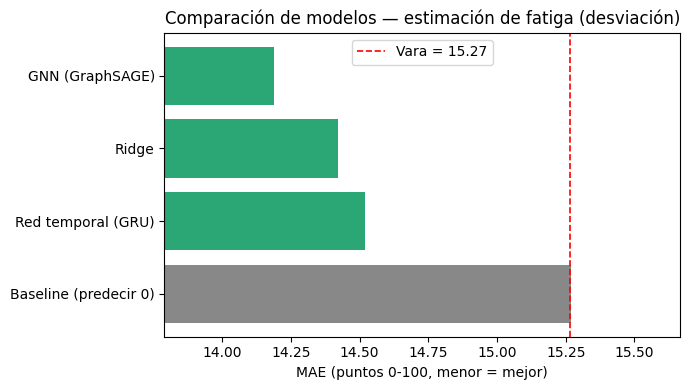

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

tabla = (pd.DataFrame({'Modelo': list(RESULTADOS), 'MAE': list(RESULTADOS.values())})
         .assign(**{'vs vara': lambda x: (x['MAE'] - mae_A).round(2)})
         .sort_values('MAE').reset_index(drop=True))
tabla['MAE'] = tabla['MAE'].round(2)
print(tabla.to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(7, 4))
t = tabla.sort_values('MAE', ascending=False)
colores = ['#888888' if m == 'Baseline (predecir 0)' else '#2aa775' for m in t['Modelo']]
ax.barh(t['Modelo'], t['MAE'], color=colores)
ax.axvline(mae_A, color='red', ls='--', lw=1.2, label=f'Vara = {mae_A:.2f}')
ax.set_xlim(min(tabla['MAE'])-0.4, mae_A+0.4)
ax.set_xlabel('MAE (puntos 0-100, menor = mejor)')
ax.set_title('Comparación de modelos — estimación de fatiga (desviación)')
ax.legend()
plt.tight_layout(); plt.show()

### Conclusión del modelo preliminar

- **Todos los modelos le ganan a la vara, pero por poco** (~0.8–1.1 puntos en escala 0–100). La señal pasiva del celular aporta *algo* sobre solo conocer el nivel normal de cada persona, pero el margen es chico.
- **La GNN quedó arriba**, probablemente porque sus aristas "misma persona" refuerzan la estructura intra-persona. Pero la diferencia con los clásicos es pequeña → conviene confirmarla con validación cruzada antes de afirmarlo.
- **Lo más importante para el informe:** este resultado, lejos de ser un fracaso, *justifica empíricamente* la arquitectura del proyecto. Si ni los modelos más modernos extraen mucha señal del uso del celular solo, eso demuestra que hace falta sumar el **PVT** y el **contexto** — exactamente el diseño de sumatoria que el equipo ya definió. El propio estudio fuente [1] ya había encontrado que la relación uso–fatiga es débil.

**Siguiente paso sugerido:** validación cruzada (repetir con varias particiones) para poner barras de error a estos números y ver si el orden se sostiene.

---
## Referencias

### Datos y dominio
**[1] Fuente del dataset (`appData.csv`).** *Fatigue, boredom and objectively measured smartphone use at work.* Royal Society Open Science, 8(7): 201915 (2021). Estudio de *experience sampling* con 83 candidatos a doctorado, fatiga y aburrimiento cada hora durante 3 días, con registro automático del uso del smartphone. https://royalsocietypublishing.org/doi/10.1098/rsos.201915

**[2] GNN para fatiga (dominio).** *FatigueNet: A hybrid graph neural network and transformer framework for real-time multimodal fatigue detection.* Scientific Reports (2025). https://www.nature.com/articles/s41598-025-00640-z

**[3] Passive sensing + deep learning (dominio).** *Deep Learning-Based Detection of Cognitive Impairment from Passive Smartphone Sensing with Routine-Aware Augmentation and Demographic Personalization.* arXiv:2509.23158 (2025). https://arxiv.org/abs/2509.23158

### Algoritmos probados (uno por modelo)
**[4] Ridge (regresión lineal regularizada).** Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems.* Technometrics, 12(1), 55–67.

**[5] LightGBM (gradient boosting).** Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* Advances in Neural Information Processing Systems 30 (NeurIPS), 3146–3154.

**[6] TabPFN (modelo fundacional tabular).** Hollmann, N., Müller, S., Purucker, L., Krishnakumar, A., Körfer, M., Hoo, S. B., Schirrmeister, R. T., & Hutter, F. (2025). *Accurate predictions on small data with a tabular foundation model.* Nature. https://www.nature.com/articles/s41586-024-08328-6

**[7] Red temporal (GRU).** Cho, K., van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation.* EMNLP 2014. (Introduce la unidad GRU.)

**[8] GNN (GraphSAGE).** Hamilton, W., Ying, Z., & Leskovec, J. (2017). *Inductive Representation Learning on Large Graphs.* Advances in Neural Information Processing Systems 30 (NeurIPS), 1024–1034. arXiv:1706.02216.

> Verifica el formato de cita (APA/IEEE) que pida tu profesor antes de la entrega.